# 01 · gnomAD allele frequency — the orthogonal reality check

**CFTR Variant Toolkit · Notebook 1 of the series**

Before you trust *any* computational prediction that a variant is "pathogenic,"
there is one cheap, powerful sanity check: **how common is this variant in the
general population?**

That number comes from **gnomAD** (the *Genome Aggregation Database*,
[gnomad.broadinstitute.org](https://gnomad.broadinstitute.org)). gnomAD v4
aggregates the DNA of **~800,000 people** who were **not** selected for having
cystic fibrosis (CF) or any single disease — it is our best available snapshot
of "normal" human genetic variation.

### Why a bench scientist should care

Missense predictors (AlphaMissense, EVE, REVEL, …) look only at the *protein
sequence and structure*. They know nothing about how often a variant actually
occurs in living humans. Population frequency is therefore an **orthogonal**
piece of evidence — it comes from a completely different kind of data. When two
orthogonal lines of evidence agree, you can trust the call more; when they
*disagree*, that disagreement is itself informative.

The key idea of this notebook, in one sentence:

> **A truly CF-causing recessive allele is almost always rare. So a "pathogenic"
> prediction sitting on top of a *common* variant is a red flag, not a discovery.**

**Provenance note (important):** every table in this toolkit carries a `source`
column. In this notebook `source == 'REAL'` everywhere — these are genuine
gnomAD v4 frequencies, not illustrative demo numbers. We keep that column
visible throughout so you never have to wonder.

In [1]:
import sys, pathlib
# `toolkit` is THIS repo's toolkit.py (one directory up) — NOT a pip
# package and nothing to do with gnomAD. The line below puts the repo
# root on sys.path so `import toolkit` resolves to ../toolkit.py.
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import toolkit as tk
import pandas as pd, numpy as np
# %matplotlib inline is a Jupyter magic: it draws matplotlib plots inline below the cell
%matplotlib inline

## What is allele frequency (AF)?

Every position in your genome comes in **two copies** (one from each parent).
Each copy is an **allele**. Across a population of *N* people there are *2N*
alleles at any given site.

$$\text{AF} = \frac{\text{number of chromosomes carrying the variant}}{\text{total number of chromosomes tested}}$$

So an AF of `0.001` means 1 in 1,000 chromosomes carries the variant; an AF of
`0.5` means half of all chromosomes carry it (that is a *coin-flip-common*
variant — clearly not a rare disease allele).

**Exome AF vs genome AF.** gnomAD reports frequency from two sequencing
strategies:

- **Exome AF** — from *exome sequencing*, which reads only the ~2% of the genome
  that codes for protein. Cheaper, so gnomAD has far more exome samples → good
  statistical power for coding (e.g. missense) variants.
- **Genome AF** — from *whole-genome sequencing*, which reads everything
  including deep introns. Fewer samples, but the **only** way to see variants
  that fall outside the exome (the deep-intronic splice variants we meet later).

For a coding variant, exome AF is usually the number you lean on. gnomAD also
publishes a combined figure; the toolkit exposes it as `gnomad_af`.

*(AF definition & the gnomAD reference dataset: Karczewski et al. 2020, *Nature*, PMID 32461654.)*

### The ACMG connection: BS1 and BA1

Clinical geneticists formalized the "too common to cause disease" logic in the **ACMG/AMP** — **A**merican **C**ollege of **M**edical **G**enetics and Genomics and the **A**ssociation for **M**olecular **P**athology — variant-classification guidelines (Richards et al. 2015, *Genet Med*, PMID 25741868). Two of
their *benign* evidence codes are pure frequency arguments:

| Code | Meaning | Rough idea |
|------|---------|-----------|
| **BA1** | *stand-alone benign* | AF is so high the variant **cannot** cause a rare recessive disease (e.g. AF > 5%). |
| **BS1** | *strong benign* | AF is *greater than expected* for the disease — too common to be a typical CF allele. |

CF is a **recessive** disease: you need a damaging variant on **both** copies of
*CFTR* to be affected. Damaging alleles are kept rare by natural selection, so
most bona-fide CF-causing variants sit at **AF < 1e-3** (below 0.1%), and many
well below 1e-4. That is the threshold intuition we will now check against real
data. (A famous exception, R117H, is discussed below — biology always has
caveats.)

## Load the real gnomAD missense table

`tk.load_gnomad_missense()` reads a cached extract of **gnomAD v4** filtered to
*CFTR* missense variants (gene `ENSG00000001626`, MANE transcript
`NM_000492.4`). A *missense* variant changes one amino acid in the protein — the
substrate that missense predictors try to score.

The columns:

| column | meaning |
|--------|---------|
| `variant_id` | genomic key `chrom-pos-ref-alt` (GRCh38) |
| `hgvs_c` | change at the DNA/coding level, e.g. `c.5A>C` |
| `hgvs_p` | change at the protein level, e.g. `p.Gln2Pro` |
| `protein_variant` | short form of the protein change, e.g. `Q2P` (the join key other tools use) |
| `consequence` | variant class — all `missense_variant` here |
| `gnomad_af` | **population allele frequency** (the star of this notebook) |
| `source` | `REAL` — genuine gnomAD data |

> **How this data is fetched.** `load_gnomad_missense()` reads a cached extract that `fetch_scores.py::fetch_gnomad_cftr` built by querying the **gnomAD GraphQL API** (`https://gnomad.broadinstitute.org/api`, gene `ENSG00000001626`, `dataset gnomad_r4` = v4.1.1) and keeping `consequence == "missense_variant"`. **No quality filter is applied** — which is why the count (2,466) exceeds the browser's PASS-only number (see the funnel below). The exact query is recorded in `data_manifest.json`.

In [2]:
missense = tk.load_gnomad_missense()

print(f"rows: {len(missense):,}   columns: {list(missense.columns)}")
print(f"source values present: {missense['source'].unique().tolist()}")
missense.head()

rows: 2,466   columns: ['variant_id', 'hgvs_c', 'hgvs_p', 'protein_variant', 'consequence', 'gnomad_af', 'source']
source values present: ['REAL']


,variant_id,hgvs_c,hgvs_p,protein_variant,consequence,gnomad_af,source
0,7-117480099-A-C,c.5A>C,p.Gln2Pro,Q2P,missense_variant,1.368251e-06,REAL
1,7-117480101-A-T,c.7A>T,p.Arg3Trp,R3W,missense_variant,2.736517e-06,REAL
2,7-117480102-G-T,c.8G>T,p.Arg3Met,R3M,missense_variant,1.778734e-05,REAL
3,7-117480104-T-C,c.10T>C,p.Ser4Pro,S4P,missense_variant,6.841246e-07,REAL
4,7-117480105-C-T,c.11C>T,p.Ser4Leu,S4L,missense_variant,2.326046e-05,REAL


In [3]:
# Sanity check that we are looking at 100% REAL data (no demo rows mixed in).
assert (missense["source"] == "REAL").all(), "unexpected non-REAL rows!"
print(f"All {len(missense):,} CFTR missense variants are source == 'REAL' (genuine gnomAD v4).")

All 2,466 CFTR missense variants are source == 'REAL' (genuine gnomAD v4).


## Where does the number **2,466** come from? The gnomAD funnel

`load_gnomad_missense()` returns **2,466** missense variants — but the gnomAD
*browser* shows **2,173** for "Missense / Inframe indel". They differ because the
toolkit's GraphQL query applies **no quality filter**, while the browser hides
**filtered** variants by default. The funnel below reconciles it (counts from the
recorded gnomAD v4.1.1 query — see the data manifest / plan F1):

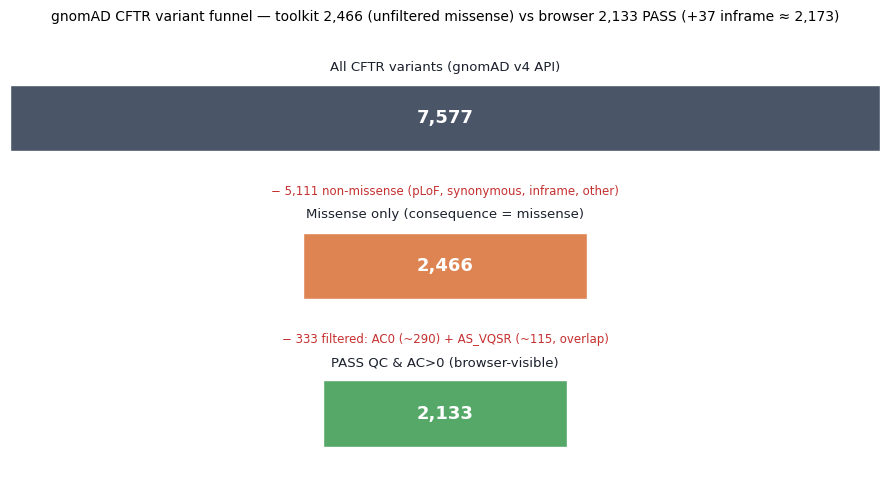

In [4]:
import matplotlib.pyplot as plt

# Counts from the recorded gnomAD v4.1.1 API query (regenerate via the recorded
# query to keep auditable — see data_manifest.json / plan F1, R23).
stages = [
    ("All CFTR variants (gnomAD v4 API)",        7577, "#4a5568"),
    ("Missense only (consequence = missense)",   2466, "#dd8452"),
    ("PASS QC & AC>0 (browser-visible)",         2133, "#55a868"),
]
drops = [
    "− 5,111 non-missense (pLoF, synonymous, inframe, other)",
    "− 333 filtered: AC0 (~290) + AS_VQSR (~115, overlap)",
]

fig, ax = plt.subplots(figsize=(9, 5))
top = stages[0][1]
gap = 2.0
for i, (label, n, color) in enumerate(stages):
    y = (len(stages) - 1 - i) * gap
    w = n / top
    ax.barh(y, w, left=(1 - w) / 2, height=0.9, color=color, edgecolor="white")
    ax.text(0.5, y, f"{n:,}", ha="center", va="center", color="white",
            fontsize=13, fontweight="bold")                       # count inside
    ax.text(0.5, y + 0.60, label, ha="center", va="bottom",
            color="#1a202c", fontsize=9.5)                        # label above (dark)
for i, d in enumerate(drops):
    ax.annotate(d, xy=(0.5, ((len(stages) - 1 - i) * gap) - gap / 2),
                ha="center", va="center", fontsize=8.5, color="#c53030")

ax.set_xlim(0, 1); ax.set_ylim(-0.9, (len(stages) - 1) * gap + 1.2); ax.axis("off")
ax.set_title("gnomAD CFTR variant funnel — toolkit 2,466 (unfiltered missense) "
             "vs browser 2,133 PASS (+37 inframe ≈ 2,173)", fontsize=10)
fig.tight_layout()
plt.show()

**Takeaway:** the toolkit's **2,466** counts *all* missense variants gnomAD
returns, including **~290 AC0** (no observed carriers after QC) and **~115
AS_VQSR-filtered** ones the browser hides. The browser's PASS + AC>0 missense count
is **2,133**; add ~37 PASS inframe indels and you get the browser's **≈2,173**. See
plan F1/R9 for whether to switch the headline count to 2,133.

## The shape of population variation: most variants are *very* rare

Allele frequencies span many orders of magnitude — from ~`1e-6` (seen on a
handful of chromosomes out of ~1.6 million) up to ~`0.5`. Plotting raw AF would
just cram everything against zero. So we plot **log10(AF)**, which spreads the
values out and makes the structure visible.

A couple of housekeeping points before the plot:

- We keep only variants with **AF > 0**. A `0` (or missing) AF means the variant
  was *never observed* in gnomAD — `log10(0)` is undefined, so those can't go on
  a log axis. (They are effectively "ultra-rare / private" and would pile up at
  the far-left edge anyway.)
- On the x-axis, **−6 means AF = 1e-6** (ultra-rare) and **−1 means AF = 0.1**
  (common). **Further left = rarer.**

2,176 variants with AF > 0 are plotted; 290 had AF == 0 / missing (never seen in gnomAD) and are omitted.


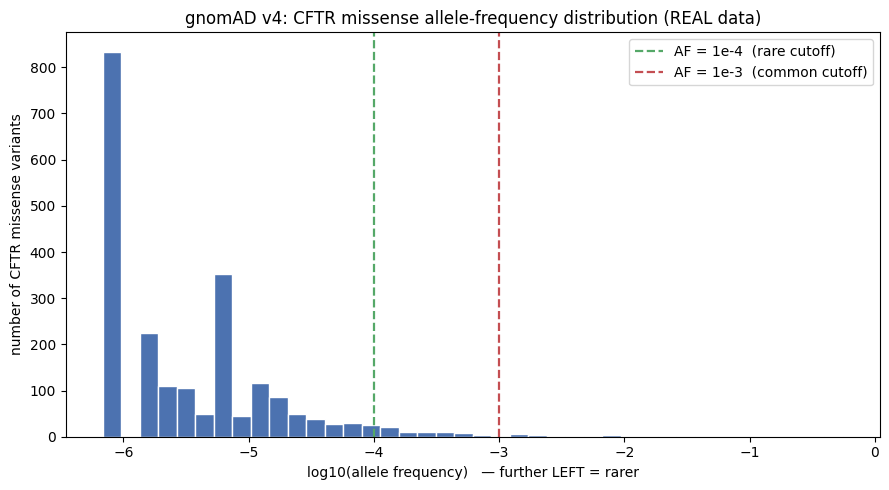

In [5]:
import matplotlib.pyplot as plt

# Keep observed variants only (AF > 0) so log10 is defined.
observed = missense[missense["gnomad_af"] > 0].copy()
observed["log10_af"] = np.log10(observed["gnomad_af"])

n_zero = len(missense) - len(observed)
print(f"{len(observed):,} variants with AF > 0 are plotted; "
      f"{n_zero:,} had AF == 0 / missing (never seen in gnomAD) and are omitted.")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(observed["log10_af"], bins=40, color="#4C72B0", edgecolor="white")

# Guide lines for the 'rare' (1e-4) and 'common' (1e-3) cut-points we use next.
ax.axvline(np.log10(1e-4), color="#55A868", linestyle="--", linewidth=1.6,
           label="AF = 1e-4  (rare cutoff)")
ax.axvline(np.log10(1e-3), color="#C44E52", linestyle="--", linewidth=1.6,
           label="AF = 1e-3  (common cutoff)")

ax.set_xlabel("log10(allele frequency)   — further LEFT = rarer")
ax.set_ylabel("number of CFTR missense variants")
ax.set_title("gnomAD v4: CFTR missense allele-frequency distribution (REAL data)")
ax.legend()
plt.tight_layout()
plt.show()

**Read the histogram left-to-right.** The mass of the distribution sits on the
**left** — the overwhelming majority of *CFTR* missense variants are rare or
ultra-rare (AF well below `1e-4`, left of the green line). Only a thin tail
reaches to the **right** of the red line into "common" territory.

This is exactly what population genetics predicts: functionally important genes
like *CFTR* tolerate very few common protein-changing variants, because most
amino-acid changes are either harmless-but-rare or removed by selection. **The
rarity of a variant is the default expectation — commonness is the exception
worth investigating.**

## Counting: rare vs common, and who the common ones are

Let's put numbers on the picture. We'll define two convenience buckets using the
thresholds from the histogram:

- **rare**: `AF < 1e-4` (below 0.01%) — the frequency band where genuine
  CF-causing alleles live.
- **common**: `AF > 1e-3` (above 0.1%) — too common for a typical recessive CF
  allele; these light up **BS1/BA1** benign evidence.

(The band between `1e-4` and `1e-3` is a grey zone we leave unlabelled here.)

In [6]:
rare   = missense[missense["gnomad_af"] < 1e-4]
common = missense[missense["gnomad_af"] > 1e-3]

print(f"rare   (AF < 1e-4): {len(rare):>5,}  ({len(rare)/len(missense):6.1%} of all missense)")
print(f"common (AF > 1e-3): {len(common):>5,}  ({len(common)/len(missense):6.1%} of all missense)")
print()
print("The common bucket is a tiny handful — and almost none of them cause CF.")

rare   (AF < 1e-4): 2,375  ( 96.3% of all missense)
common (AF > 1e-3):    18  (  0.7% of all missense)

The common bucket is a tiny handful — and almost none of them cause CF.


In [7]:
# Show every 'common' variant, most-common first. These are the BS1/BA1 flags.
common_sorted = common.sort_values("gnomad_af", ascending=False)
common_sorted[["protein_variant", "hgvs_c", "hgvs_p", "gnomad_af", "source"]].reset_index(drop=True)

,protein_variant,hgvs_c,hgvs_p,gnomad_af,source
0,V470M,c.1408G>A,p.Val470Met,0.557362,REAL
1,R75Q,c.224G>A,p.Arg75Gln,0.031280,REAL
2,N417K,c.1251C>A,p.Asn417Lys,0.020361,REAL
3,R668C,c.2002C>T,p.Arg668Cys,0.008450,REAL
4,S1235R,c.3705T>G,p.Ser1235Arg,0.008051,REAL
5,G576A,c.1727G>C,p.Gly576Ala,0.006994,REAL
6,D1270N,c.3808G>A,p.Asp1270Asn,0.004158,REAL
7,R74W,c.220C>T,p.Arg74Trp,0.004157,REAL
8,E217G,c.650A>G,p.Glu217Gly,0.003384,REAL
9,R117H,c.350G>A,p.Arg117His,0.002199,REAL


### Interpreting the common list

Notice `source` is still `REAL` for every row — these frequencies are real.

- **The top entry, `V470M` (AF ≈ 0.56), is the classic teaching example.** It is
  the common **M470V polymorphism** of *CFTR* (you'll see it written either way
  depending on which allele the database treats as reference; here the
  alternate allele is the *M→V* direction, hence `V470M`). It occurs on **more
  than half** of all human chromosomes. A variant that common **cannot** be a
  penetrant CF-causing allele — it is a benign polymorphism, a **BA1** call. If a
  missense predictor ever flags it as "pathogenic," that is a failure of the
  predictor, not a discovery about the patient.

- Most other rows (`R668C`, `R75Q`, `S1235R`, …) are likewise **benign or
  low-impact** — far too common to be classic CF alleles.

- **The instructive exception is `R117H` (AF ≈ 2e-3).** It is genuinely
  *CF-causing but mild/variable*, and it is relatively common **because** its
  effect is mild (weak selection lets it persist). This is the caveat to keep
  you honest: "common ⇒ benign" is a strong **prior**, not an absolute law. The
  frequency filter flags candidates for scrutiny; it does not overrule
  functional and clinical evidence on its own. This nuance is exactly why ACMG
  distinguishes stand-alone **BA1** from merely-strong **BS1**.

## Beyond missense: the variants your protein predictor can't see

A missense predictor only scores changes to the **amino-acid sequence**. But a
lot of *CFTR* pathology hides in variants that leave the protein sequence
untouched — deep in introns, in synonymous ("silent") codons, or right at the
edges of exons where the **splicing** machinery reads the RNA.

`tk.load_gnomad_noncoding()` loads the *CFTR* variants from the **same real
gnomAD v4** source, but from these non-missense consequence classes. Because
many of them live outside the exome, this table also exposes separate
`exome_af` and `genome_af` columns.

In [8]:
noncoding = tk.load_gnomad_noncoding()

print(f"rows: {len(noncoding):,}   source: {noncoding['source'].unique().tolist()}")
print(f"columns: {list(noncoding.columns)}")

# Consequence breakdown — what KINDS of non-coding variation are here.
noncoding["consequence"].value_counts()

rows: 4,717   source: ['REAL']
columns: ['variant_id', 'hgvs_c', 'hgvs_p', 'consequence', 'exome_af', 'genome_af', 'gnomad_af', 'source']


consequence
intron_variant             3325
synonymous_variant          736
splice_region_variant       239
3_prime_UTR_variant         224
5_prime_UTR_variant          83
splice_acceptor_variant      56
splice_donor_variant         54
Name: count, dtype: int64

### Why this breakdown motivates a whole separate analysis

Read the counts above:

- **`intron_variant`** dominates. Most are harmless, but a small number are
  **deep-intronic splice variants** that create a *cryptic* splice site and
  wreck the transcript — classic CF alleles like `c.3849+10kbC>T` live here.
  They are **completely invisible** to any missense predictor, because they
  never change an amino acid.
- **`synonymous_variant`** ("silent") changes look harmless — same protein — yet
  a few disrupt splicing regulatory elements near exon boundaries.
- **`splice_acceptor_variant` / `splice_donor_variant` / `splice_region_variant`**
  sit right at the exon–intron junctions the spliceosome depends on.

None of these are scoreable by AlphaMissense, EVE, REVEL, or ESM1b. They need a
different class of tool — **splice predictors** such as SpliceAI and Pangolin —
which is the subject of a later notebook. The point for *this* notebook: gnomAD
frequency is the one filter that applies **uniformly** across *all* of these
classes, coding and non-coding alike.

## Example: the shared A1 worked-example panel, scored by **gnomAD allele frequency**

The same fixed panel of famous CFTR **missense** variants runs through every A1 tool
(notebooks 01–08), so you can follow one set of variants across the series. The
variant list is `tk.A1_PANEL_VARIANTS` / `tk.A2_KNOWN_CDNA` (shared in `toolkit.py`); the
**scoring is shown inline below** so you can see exactly how gnomAD allele frequency is joined onto it.

> The assembled cross-tool table for all tools at once is `tk.a1_panel()()`.

In [9]:
# Score the shared A1 panel with THIS tool, inline (so you see the join).
# The variant list lives in toolkit (tk.A1_PANEL_VARIANTS); the scoring is shown here.
panel = tk.A1_PANEL_VARIANTS
g = tk.load_gnomad_missense()
g[g['protein_variant'].isin(panel)][['protein_variant', 'consequence', 'gnomad_af']].reset_index(drop=True)

,protein_variant,consequence,gnomad_af
0,G85E,missense_variant,0.000065
1,R117H,missense_variant,0.002199
2,Y161C,missense_variant,0.000002
3,P205S,missense_variant,0.000007
4,R334W,missense_variant,0.000092
5,V520F,missense_variant,0.000029
6,G551D,missense_variant,0.000404
7,R668C,missense_variant,0.008450
8,S912L,missense_variant,0.000663
9,H949Y,missense_variant,0.000003


## Key takeaways

1. **gnomAD v4 (~800k people) is your orthogonal reality check.** It is
   independent of any sequence-based predictor, so it can *confirm* or *challenge*
   a computational call rather than just echo it.

2. **Rare is the default; common is the red flag.** The real *CFTR* missense
   distribution is overwhelmingly rare (AF < 1e-4). A "pathogenic" prediction on
   a *common* variant should make you suspicious of the prediction — this is the
   ACMG **BS1** (strong benign) / **BA1** (stand-alone benign) logic.

3. **A concrete example:** `V470M`/`M470V` sits at AF ≈ 0.56 — over half of all
   chromosomes. It is a benign polymorphism, full stop. Any tool calling it
   pathogenic is wrong.

4. **But "common ⇒ benign" is a strong prior, not a law.** `R117H` is a genuinely
   CF-causing yet relatively common *mild* allele. Use frequency to *triage and
   flag*, and let functional / clinical evidence adjudicate the edge cases.

5. **Frequency is universal; missense predictors are not.** gnomAD frequency
   applies to intronic, synonymous, and splice variants that no protein-level
   predictor can score — motivating the separate splice analysis to come.

6. **Provenance stayed visible the whole way.** Every table here was
   `source == 'REAL'`. Keep that column in view so REAL gnomAD data is never
   silently confused with illustrative demo values elsewhere in the toolkit.

**Next up:** feed these same variants into the missense predictors and watch how
often their calls line up with — or diverge from — this frequency evidence.